# Library

In [1]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
accuracy_score,
classification_report,
roc_auc_score, 
roc_curve)
from sklearn.utils import resample 
import seaborn as sns

# Load File

### Check missing value,...

In [2]:
df = pd.read_csv('Data/heart..csv')
df.head() #see the columns and values
df.info() #check data type and missing value 

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64(12), str(1)
memo

In [3]:
df.isnull().sum()  #detect missing or null values 
#if the outputs are all zero = good, else impute
df.duplicated().sum()

np.int64(0)

In [4]:
df = df.fillna(df.median(numeric_only=True))  #median imputation
# df.fillna() used to replace missing value (NaN) in Df or Series with specified value

In [5]:
#turn string label into the numeric label
df['Heart Disease'] = df['Heart Disease'].map({'Presence':1, 
                                               'Absence':0})
# df['Heart Disease'] = df['Heart Disease'].apply(lambda x: 1 if x == 'Presence' else 0)
df['Heart Disease'].value_counts()


Heart Disease
0    150
1    120
Name: count, dtype: int64

In [6]:
X = df.drop('Heart Disease', axis=1)  # X--> Predictors and Y--> Target 
y = df['Heart Disease']

In [7]:
for col in X.columns:
    print(col, X[col].nunique())


Age 41
Sex 2
Chest pain type 4
BP 47
Cholesterol 144
FBS over 120 2
EKG results 3
Max HR 90
Exercise angina 2
ST depression 39
Slope of ST 3
Number of vessels fluro 4
Thallium 3


# One-hot encoding

In [8]:
categorical_cols = ['Chest pain type', 
                    'EKG results',
                    'Slope of ST',
                    'Thallium'
                   ]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True) 
#converts categorical variables into dummy/indicator variables (known as one-hot encoding)

X.describe()

,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000
mean,54.433333,0.677778,131.344444,249.659259,0.148148,149.677778,0.329630,1.05000,0.670370
std,9.109067,0.468195,17.861608,51.686237,0.355906,23.165717,0.470952,1.14521,0.943896
min,29.000000,0.000000,94.000000,126.000000,0.000000,71.000000,0.000000,0.00000,0.000000
25%,48.000000,0.000000,120.000000,213.000000,0.000000,133.000000,0.000000,0.00000,0.000000
50%,55.000000,1.000000,130.000000,245.000000,0.000000,153.500000,0.000000,0.80000,0.000000
75%,61.000000,1.000000,140.000000,280.000000,0.000000,166.000000,1.000000,1.60000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,202.000000,1.000000,6.20000,3.000000


## Heat Map 
### Check correlation

<Axes: >

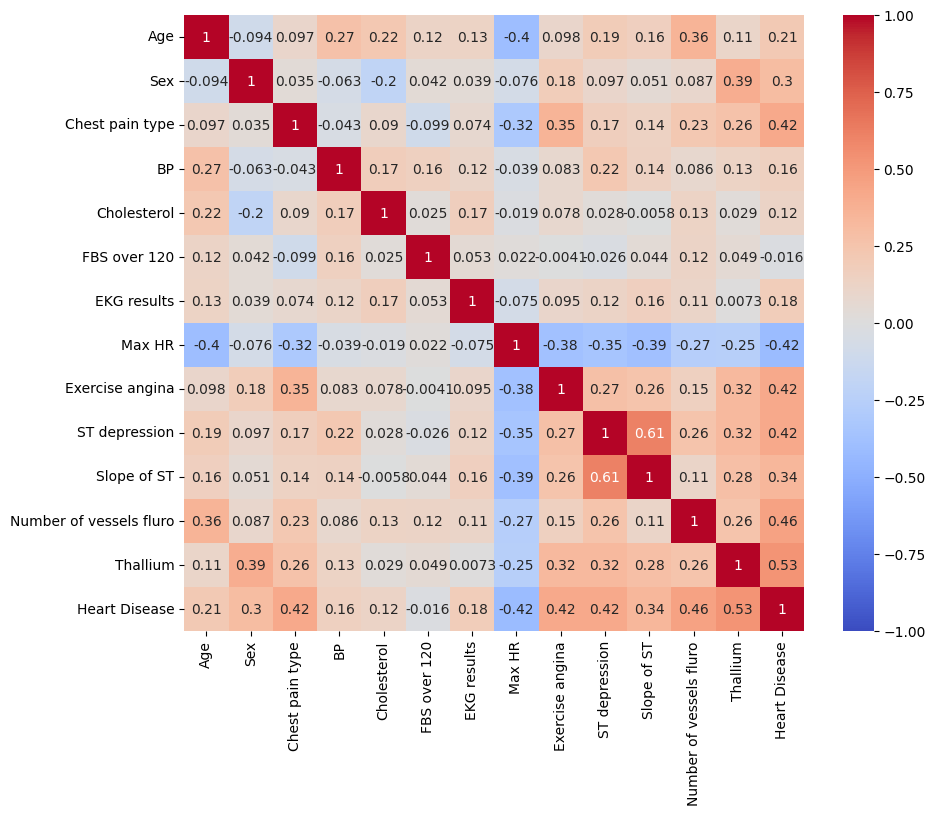

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot = True, cmap="coolwarm", vmin=-1, vmax=1)

# Train Split 

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42, 
                                                    stratify=y
                                                    )

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,
                                                test_size = 0.5,
                                                random_state = 42
                                               )

# Scale the X resample

In [11]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Train the model

In [12]:
model = LogisticRegression(max_iter=1000, solver='lbfgs') 
# to avoid convergence and set a stable and default solver for binary classification 
model.fit(X_train_scaled, y_train)
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)


Coefficients: [[-0.04127754  0.9999921   0.33484415  0.3455923  -0.15031061 -0.36109074
   0.21039793  0.16916715  1.10273473  0.17897852  0.0933846   0.929555
   0.20314997  0.04328683  0.72855248  0.12644974  0.0353735   0.52540011]]
Intercept: [-0.25542217]


# Prediction

In [13]:
y_val_pred = model.predict(X_val_scaled)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))


y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

Validation Accuracy: 0.825


# Confusion Matrix

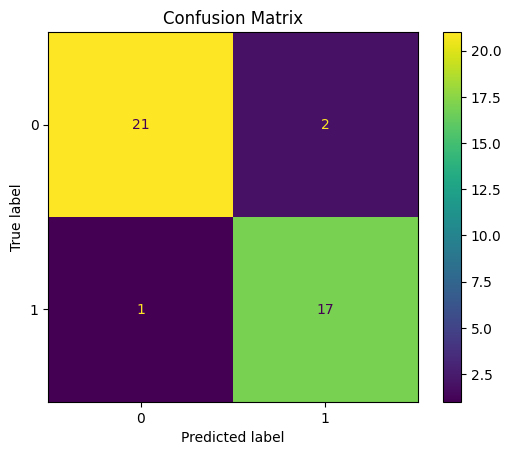

In [14]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [15]:
accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93        23
           1       0.89      0.94      0.92        18

    accuracy                           0.93        41
   macro avg       0.92      0.93      0.93        41
weighted avg       0.93      0.93      0.93        41



# ROC AUC to measure the accuracy

In [16]:

print(f'The ROC_AUC score is {roc_auc_score(y_test, y_pred_proba)*100:.2f}%')
    

The ROC_AUC score is 94.44%


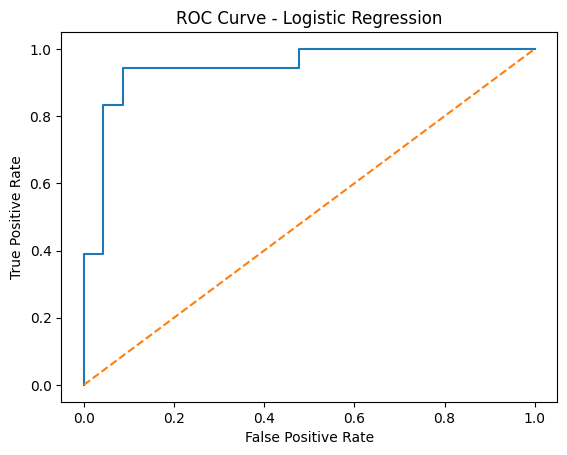

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()


## Save the model

In [18]:

import joblib

filename = joblib.dump(model, "model.saved")
print(filename[0], "is successfully saved")


joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

model.saved is successfully saved


['columns.pkl']